<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [17]</a>'.</span>

# [v2] Trajectory classification — GELSTM with per-fold FDR filtering

Same task as `LONGITUDINAL_GELSTM_DELCODE_WHOLE_BRAIN.ipynb` (**trajectory**,
not early detection) — adds per-fold FDR-based selection of GAAE latent dims.


In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to outputs/<experiment-id>/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name


In [2]:
# Parameters
EXPERIMENT_ID = "gelstm-trajectory-fdr"
MODE = "longitudinal"
MODEL = "GELSTM"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = "notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth"
THRESHOLD_MODE = "best-f1"
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/gelstm-trajectory-fdr"
RESOLVED_CONFIG = {"epochs": 50, "lr": 0.001, "batch_size": 16, "grad_clip": 1.0, "early_stopping_patience": 15, "use_scheduler": True, "seed": 42, "threshold_mode": "youden", "fixed_threshold": 0.5, "lr_factor": 0.5, "lr_patience": 5, "lr_min": 1e-06, "use_time_delta": True, "zero_time_delta": False, "graph_pool": "mean", "dim_filter": None, "shuffle_order": False, "shuffle_rng": None, "top_k": 15, "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3, "classifier_hidden": 64, "freeze_encoder": True, "learning_rate": 0.001, "use_class_cost_weights": True, "n_folds": 5}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gelstm-trajectory-fdr/runs/balmy-spark-2-349c3823d-2026-06-20_09-20-16"
RUN_NAME = "balmy-spark-2-349c3823d-2026-06-20_09-20-16"


# GELSTM FDR-Filtered — Longitudinal MCI Conversion Classifier

Identical to `GELSTM_DELCODE_WHOLE_BRAIN.ipynb` except:

- The 64-D GAAE embedding is **projected to the top-K most discriminative latent dimensions** (ranked by Fisher's Discriminant Ratio, computed on train+val only — no test leakage).
- LSTM input: `(TOP_K + 1)` dimensions instead of `(gaae_latent + 1)`.

**Motivation**: FDR analysis in `GAAE_LATENT_SPACE_VISUALIZER.ipynb` shows that a small subset of dimensions (e.g. dim 59, 30, 24, 16, 18) carry most of the discriminative signal. Projecting to this subspace reduces LSTM input noise and overfitting risk, which is particularly important given the small converter cohort (n=54).

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# v2 reproducibility seeding — must run before datasets, samplers, or models.
from CLASSIFIER.common.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


In [5]:
import json, os, copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report
from torch_geometric.loader import DataLoader
from torch_geometric.utils import unbatch
from model.GELSTM.models  import GELSTMClassifier
from model.GELSTM.dataset import LongitudinalSubjectDataset
from model.GELSTM.train   import train_epoch, evaluate, make_batches
from model.GELSTM.utils   import compute_class_weights, encode_batch_sequences
from model.GAAE.models    import GraphAttentionAutoencoderConditioned
from model.GAAE.dataset   import GraphDatasetInMemoryFiltered
from model.GAAE.utils     import knn_binary_adjacency_matrix_no_diag
from common.fdr import compute_fdr_filter
from common.provenance import (
    region_from_data_root, make_run_dir, snapshot_source,
    save_full_checkpoint, write_run_summary, patch_run_summary,
    capture_env, capture_git_provenance,
)
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Configuration

In [7]:
import sys
if '/mnt/e/fyassine/ad-early-detection' not in sys.path:
    sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────
WB_DATA_ROOT  = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR  = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV   = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR    = str(splits_dir('downstream'))
TRAIN_CSV     = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV       = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV      = os.path.join(SPLITS_DIR, 'test.csv')

# Brain region / atlas parsed from the DATA directory name. Surfaced in the run
# name and stored in the run config so the input data is visible at a glance.
DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}  ({DATA_INFO['dataset_dir']})")

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain'),
    str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_dmn'),
]
OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gelstm_fdr_filtered')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── GAAE encoder config (must match checkpoint) ──────────────────────────
CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'

# ── This notebook's training hyper-params (loaded from configs/, inline fallback) ─
TRAIN_CONFIG_PATH = model_root / 'configs' / 'gelstm_fdr_filtered_delcode.json'
_train_defaults = {
    'top_k': 15, 'lstm_hidden': 128, 'lstm_layers': 2, 'lstm_dropout': 0.3,
    'classifier_hidden': 64, 'use_time_delta': True, 'graph_pool': 'mean',
    'freeze_encoder': True, 'learning_rate': 1e-3, 'epochs': 50,
    'early_stopping_patience': 15, 'batch_size': 16, 'use_class_cost_weights': True,
    'grad_clip': 1.0, 'n_folds': 5,
}
if TRAIN_CONFIG_PATH.exists():
    with open(TRAIN_CONFIG_PATH) as _f:
        TRAIN_CONFIG = json.load(_f)
    print(f'Loaded training config from {TRAIN_CONFIG_PATH}')
else:
    TRAIN_CONFIG = _train_defaults
    print(f'Training config not found at {TRAIN_CONFIG_PATH} — using inline defaults.')

# Runner override: merge injected RESOLVED_CONFIG (YAML hyperparams) over JSON config.
if RESOLVED_CONFIG:
    TRAIN_CONFIG = {**TRAIN_CONFIG, **RESOLVED_CONFIG}
    print('Applied RESOLVED_CONFIG overrides from runner.')

TOP_K                   = TRAIN_CONFIG['top_k']
LSTM_HIDDEN             = TRAIN_CONFIG['lstm_hidden']
LSTM_LAYERS             = TRAIN_CONFIG['lstm_layers']
LSTM_DROPOUT            = TRAIN_CONFIG['lstm_dropout']
CLASSIFIER_HIDDEN       = TRAIN_CONFIG['classifier_hidden']
USE_TIME_DELTA          = TRAIN_CONFIG['use_time_delta']
GRAPH_POOL              = TRAIN_CONFIG['graph_pool']
FREEZE_ENCODER          = TRAIN_CONFIG['freeze_encoder']
LEARNING_RATE           = TRAIN_CONFIG['learning_rate']
EPOCHS                  = TRAIN_CONFIG['epochs']
EARLY_STOPPING_PATIENCE = TRAIN_CONFIG['early_stopping_patience']
BATCH_SIZE              = TRAIN_CONFIG['batch_size']
USE_CLASS_COST_WEIGHTS  = TRAIN_CONFIG['use_class_cost_weights']
GRAD_CLIP               = TRAIN_CONFIG['grad_clip']
N_FOLDS                 = TRAIN_CONFIG['n_folds']

print('Config set.')

Input data: region=wholebrain  atlas=sch200  (__fc_wholebrain_sch200_flat__)
Loaded training config from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/configs/gelstm_fdr_filtered_delcode.json
Applied RESOLVED_CONFIG overrides from runner.
Config set.


In [8]:
# v2 split-hygiene audit — hard-fails if any subject crosses splits.
import sys
from pathlib import Path
_REPO_ROOT = Path('/mnt/e/fyassine/ad-early-detection')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
_V2_ROOT = _REPO_ROOT / 'CLASSIFIER'
if str(_V2_ROOT) not in sys.path:
    sys.path.insert(0, str(_V2_ROOT))
from common.sanity import run_full_audit
from DATA.src.splitting.load_splits import split_csv_paths
_ = run_full_audit(split_csv_paths('downstream'))


[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Select GAAE Checkpoint

In [9]:
checkpoint_candidates = sorted(
    [(run_dir.name, str(run_dir / f'model_{run_dir.name}.pth'), str(run_dir))
     for ckpt_dir in CHECKPOINT_SEARCH_DIRS
     for base_path in [Path(ckpt_dir)] if base_path.is_dir()
     for run_dir in sorted(base_path.iterdir()) if run_dir.is_dir()
     if (run_dir / f'model_{run_dir.name}.pth').exists()],
    key=lambda x: x[0],
)
if not checkpoint_candidates:
    raise FileNotFoundError('No GAAE checkpoints found.')
print('Available GAAE checkpoints:')
for i,(name,_,_) in enumerate(checkpoint_candidates): print(f'  {i}: {name}')
if GAAE_CHECKPOINT_PATH is not None:
    _t = str(Path(GAAE_CHECKPOINT_PATH).resolve())
    _m = [c for c in checkpoint_candidates if str(Path(c[1]).resolve()) == _t]
    if not _m:
        raise FileNotFoundError(f'GAAE_CHECKPOINT_PATH={GAAE_CHECKPOINT_PATH!r} not among '
                                f'candidates: {[c[1] for c in checkpoint_candidates]}')
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = _m[0]
elif RUN_DIR is not None:
    raise ValueError(
        "GAAE_CHECKPOINT_PATH is required under the experiment runner. "
        "Set 'checkpoint_path:' on this entry in experiments.yaml."
    )
else:
    selected_idx = int(input('Select checkpoint index: '))
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = checkpoint_candidates[selected_idx]
print(f'Selected: {GAAE_RUN_NAME}')


Available GAAE checkpoints:
  0: dark-blaze-8_2026-03-24_01-53-42
  1: ethereal-planet-16_2026-06-10_12-31-05
Selected: ethereal-planet-16_2026-06-10_12-31-05


## Load GAAE Config

In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
    print('Config loaded:', hp)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
    print('Config not found – using defaults.')

IN_FEATURES  = 200
GAAE_HIDDEN  = hp.get('hidden_dim', 128)
GAAE_LATENT  = hp.get('latent_dim', 64)
GAAE_HEADS   = hp.get('num_heads', 2)
GAAE_COND_DIM = hp.get('cond_dim', 2)
GAAE_DROPOUT  = hp.get('dropout', 0.3)
ADJ_K         = hp.get('adjacency_k', 8)
FILE_VARIANT  = hp.get('file_variant', 'z_transformed')

# LSTM input dim is TOP_K (+1 if Δt)
LSTM_INPUT_DIM = TOP_K + (1 if USE_TIME_DELTA else 0)
print(f'GAAE hidden dim: {GAAE_HIDDEN}  latent dim: {GAAE_LATENT}  →  TOP_K={TOP_K}  LSTM_INPUT_DIM={LSTM_INPUT_DIM}')


Config loaded: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}
GAAE hidden dim: 128  latent dim: 64  →  TOP_K=15  LSTM_INPUT_DIM=16


## FDR Dimension Selection (train+val only)

Encodes all train+val MCI+converter subjects through the frozen GAAE encoder, then computes Fisher's Discriminant Ratio per latent dimension to identify the top discriminative subspace.

> **No test data used here** — `TEST_CSV` subjects are excluded.

In [11]:
import tempfile

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# CV pool (train+val) — test held out
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
mci_pool   = cv_pool_df.copy()
test_mci   = test_df.copy()

# Build merged patient-info CSV for sex/age lookup
ALL_INFO_CSV = os.path.join(SPLITS_DIR, '_all_splits_patient_info.csv')
if not os.path.exists(ALL_INFO_CSV):
    _info = pd.concat(
        [df[['Pseudonym','sex','age']] for df in [train_df, val_df, test_df]],
        ignore_index=True,
    ).drop_duplicates('Pseudonym').reset_index(drop=True)
    _info.to_csv(ALL_INFO_CSV, index=False)
    print(f'Wrote {ALL_INFO_CSV}')

adjacency_args = {'k': ADJ_K}

# Build scan-level dataset for FDR computation (train+val MCI only)
_tmp = tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w')
mci_pool.to_csv(_tmp.name, index=False)
_tmp.close()

fdr_dataset = GraphDatasetInMemoryFiltered(
    root=WB_DATA_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    filter_csv_path=_tmp.name,
    patient_info_path=ALL_INFO_CSV,
    separator=',',
    file_variant=FILE_VARIANT,
)
print(f'FDR dataset: {len(fdr_dataset)} scans (train+val MCI+converter)')


Processing...


Done!


FDR dataset: 408 scans (train+val MCI+converter)


In [12]:
# Load GAAE encoder for FDR embedding extraction
gaae_enc = GraphAttentionAutoencoderConditioned(
    in_features=IN_FEATURES, hidden_dim=GAAE_HIDDEN,
    out_features=GAAE_LATENT, cond_dim=GAAE_COND_DIM,
    num_heads=GAAE_HEADS, dropout=GAAE_DROPOUT,
).to(device)
ckpt_obj = torch.load(GAAE_CKPT_PATH, map_location=device, weights_only=False)
gaae_enc.load_state_dict(ckpt_obj if isinstance(ckpt_obj, dict) else ckpt_obj.state_dict())
gaae_enc.eval()
for p in gaae_enc.parameters(): p.requires_grad_(False)
print('GAAE encoder loaded and frozen for FDR computation.')

# Encode all train+val MCI scans → (N_scans, GAAE_LATENT)
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.utils import unbatch

fdr_loader = PyGLoader(fdr_dataset, batch_size=32, shuffle=False)
fdr_embs, fdr_labels, fdr_pids = [], [], []
id2diag_cv = dict(zip(mci_pool['Pseudonym'].astype(str), mci_pool['diagnosis']))

gaae_enc.eval()
with torch.no_grad():
    for batch in fdr_loader:
        batch = batch.to(device)
        z = gaae_enc.encode(batch.x, batch.edge_index, batch.edge_attr)
        z_list = unbatch(z, batch.batch)
        pids = batch.patient_id if isinstance(batch.patient_id, list) else [batch.patient_id]
        for z_g, pid in zip(z_list, pids):
            emb = z_g.mean(0).cpu().numpy()
            pid_str = str(pid).split('_')[0] if '_' in str(pid) else str(pid)
            diag = id2diag_cv.get(pid_str, 'mci')
            fdr_embs.append(emb)
            fdr_labels.append(1 if diag == 'converter' else 0)
            fdr_pids.append(pid_str)

fdr_embs   = np.stack(fdr_embs)
fdr_labels = np.array(fdr_labels)
print(f'Encoded {fdr_embs.shape[0]} scans  converter={fdr_labels.sum()}  mci={(1-fdr_labels).sum()}')


GAAE encoder loaded and frozen for FDR computation.


Encoded 408 scans  converter=181  mci=227


In [13]:
# Compute FDR per latent dimension
conv_emb_fdr = fdr_embs[fdr_labels == 1]
mci_emb_fdr  = fdr_embs[fdr_labels == 0]

mu_conv  = conv_emb_fdr.mean(axis=0)
mu_mci   = mci_emb_fdr.mean(axis=0)
var_conv  = conv_emb_fdr.var(axis=0)  + 1e-8
var_mci   = mci_emb_fdr.var(axis=0)   + 1e-8

fdr_scores = (mu_conv - mu_mci) ** 2 / (var_conv + var_mci)
top_dims   = np.argsort(fdr_scores)[::-1]   # descending
DIM_FILTER = top_dims[:TOP_K].copy()   # .copy() ensures contiguous array (no negative strides)

print(f'Top-{TOP_K} dimensions by FDR:')
for rank, dim_j in enumerate(DIM_FILTER):
    print(f'  #{rank+1:2d}  dim_{dim_j:3d}  FDR={fdr_scores[dim_j]:.4f}')

print(f'\nMean FDR (all dims): {fdr_scores.mean():.4f}')
print(f'Mean FDR (top-{TOP_K}): {fdr_scores[DIM_FILTER].mean():.4f}')


Top-15 dimensions by FDR:
  # 1  dim_ 50  FDR=0.6729
  # 2  dim_ 46  FDR=0.6706
  # 3  dim_ 12  FDR=0.5806
  # 4  dim_ 39  FDR=0.5632
  # 5  dim_ 58  FDR=0.5502
  # 6  dim_ 52  FDR=0.5450
  # 7  dim_ 62  FDR=0.5420
  # 8  dim_ 33  FDR=0.5037
  # 9  dim_ 47  FDR=0.5030
  #10  dim_ 10  FDR=0.4942
  #11  dim_ 22  FDR=0.4685
  #12  dim_ 38  FDR=0.4669
  #13  dim_ 40  FDR=0.4669
  #14  dim_ 35  FDR=0.4553
  #15  dim_ 61  FDR=0.4420

Mean FDR (all dims): 0.2364
Mean FDR (top-15): 0.5283


In [14]:
# Per-fold FDR plots are generated inside the CV loop below.
# (Global FDR was removed to eliminate feature-selection leakage.)
print("FDR dimension selection will run per-fold inside the CV loop.")


FDR dimension selection will run per-fold inside the CV loop.


## Build FDR-Filtered GELSTM Model

In [15]:
def build_model():
    """Build GELSTMClassifier with LSTM input dim = TOP_K (+ 1 if Δt)."""
    m = GELSTMClassifier(
        in_features=IN_FEATURES,    gaae_hidden=GAAE_HIDDEN,
        gaae_latent=GAAE_LATENT,    gaae_heads=GAAE_HEADS,
        gaae_cond_dim=GAAE_COND_DIM, gaae_dropout=GAAE_DROPOUT,
        lstm_hidden=LSTM_HIDDEN,    lstm_layers=LSTM_LAYERS,
        lstm_dropout=LSTM_DROPOUT,  use_time_delta=USE_TIME_DELTA,
        classifier_hidden=CLASSIFIER_HIDDEN,
    ).to(device)
    m.load_gaae_weights(GAAE_CKPT_PATH, device=device)
    if not FREEZE_ENCODER:
        m.unfreeze_encoder()

    # ── Patch LSTM to accept TOP_K (+1) input instead of GAAE_LATENT (+1) ──
    # The encoder still outputs GAAE_LATENT dims; DIM_FILTER selects TOP_K
    # before the LSTM. We need to rebuild the LSTM and classifier with the
    # correct input size.
    import torch.nn as nn
    lstm_in = TOP_K + (1 if USE_TIME_DELTA else 0)
    m.lstm = nn.LSTM(
        input_size=lstm_in, hidden_size=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS, batch_first=True,
        dropout=LSTM_DROPOUT if LSTM_LAYERS > 1 else 0.0,
    ).to(device)
    if CLASSIFIER_HIDDEN > 0:
        m.classifier = nn.Sequential(
            nn.Linear(LSTM_HIDDEN, CLASSIFIER_HIDDEN), nn.ReLU(),
            nn.Dropout(LSTM_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN, 1),
        ).to(device)
    else:
        m.classifier = nn.Linear(LSTM_HIDDEN, 1).to(device)

    trainable = sum(p.numel() for p in m.get_trainable_params())
    total     = sum(p.numel() for p in m.parameters())
    print(f'Model built: lstm_input={lstm_in}  trainable={trainable:,}  total={total:,}')
    return m

_ = build_model()


[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth
Model built: lstm_input=16  trainable=722,313  total=1,167,305


## Load Longitudinal Datasets

In [16]:
cv_dataset   = LongitudinalSubjectDataset(WB_DATA_ROOT, mci_pool, COHORTS_CSV,
                                          adjacency_k=ADJ_K, file_variant=FILE_VARIANT)
test_dataset = LongitudinalSubjectDataset(WB_DATA_ROOT, test_mci, COHORTS_CSV,
                                          adjacency_k=ADJ_K, file_variant=FILE_VARIANT)

cv_labels      = cv_dataset.get_labels()
cv_subject_ids = cv_dataset.get_subject_ids()
print(f'CV: {len(cv_dataset)} subjects  Test: {len(test_dataset)} subjects')


LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0
LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9
CV: 133 subjects  Test: 34 subjects


## 5-Fold CV with Per-Fold FDR-Filtered Embeddings

Each fold computes its own `DIM_FILTER` from **training subjects only**, then uses it via `encode_batch_sequences(dim_filter=DIM_FILTER)` for both training and validation within that fold. This eliminates the feature-selection leakage that existed when FDR was computed globally on the full CV pool before the loop.

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

Pre-loading all CV items...


  133 subjects loaded


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: Run data is saved locally in /mnt/e/fyassine/ad-early-detection/CLASSIFIER/wandb/run-20260620_092036-q61ttrl8
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run gelstm-trajectory-fdr


wandb: ⭐️ View project at https://wandb.ai/lakhalfrajyassine-technical-university-of-munich/ad-early-detection


wandb: 🚀 View run at https://wandb.ai/lakhalfrajyassine-technical-university-of-munich/ad-early-detection/runs/q61ttrl8



Fold 1/5  train=106  val=27
  [Fold 1] FDR top-15: [62, 46, 35, 39, 10, 47, 50, 43, 33, 12, 52, 61, 40, 58, 26]


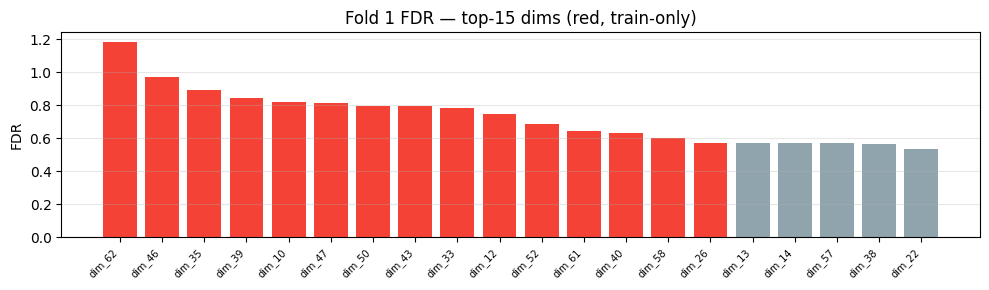

[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth
Model built: lstm_input=16  trainable=722,313  total=1,167,305


  Epoch   5/50  loss=0.6919  val_auc=0.9034


  Epoch  10/50  loss=0.4439  val_auc=0.9205


  Epoch  15/50  loss=0.4085  val_auc=0.9318


  Epoch  20/50  loss=0.3973  val_auc=0.9489


  Epoch  25/50  loss=0.3542  val_auc=0.9545


  Epoch  30/50  loss=0.3064  val_auc=0.9545


  Epoch  35/50  loss=0.3170  val_auc=0.9545


  Early stopping at epoch 36


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [17]:
cv_results = {'fold':[],'val_auc':[],'val_sensitivity':[],'val_specificity':[],'val_f1':[],'best_threshold':[]}
cv_histories = {'train_loss':[],'val_loss':[]}
oof_preds, oof_targets, oof_subject_ids = [], [], []

best_val_auc, best_fold, best_model_state = 0.0, -1, None
best_threshold_overall = 0.5
best_f1_threshold      = 0.5
cv_dim_filters   = []    # one DIM_FILTER per fold
best_dim_filter  = None  # DIM_FILTER from the best-AUC fold

print('Pre-loading all CV items...')
cv_items = [cv_dataset[i] for i in range(len(cv_dataset))]
print(f'  {len(cv_items)} subjects loaded')

from common import tracking
_wb_exp = {'id': EXPERIMENT_ID or 'gelstm-trajectory-fdr', 'mode': MODE or 'longitudinal', 'model': MODEL or 'GELSTM', 'dataset': DATASET or REGION, 'seed': SEED, 'wandb': WANDB_ENABLED}
wandb_run = tracking.init_run(_wb_exp, {**(RESOLVED_CONFIG or {}), 'REGION': REGION})

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS)

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(
    cv_items, cv_labels, groups=cv_subject_ids
)):
    print(f'\n{"="*55}')
    print(f'Fold {fold+1}/{N_FOLDS}  train={len(tr_idx)}  val={len(va_idx)}')

    tr_items  = [cv_items[i] for i in tr_idx]
    va_items  = [cv_items[i] for i in va_idx]
    tr_labels_fold = [cv_labels[i] for i in tr_idx]

    # ── Per-fold FDR dimension selection (train subjects only) ───────────
    # Map CV dataset subjects → fdr_embs rows (by subject_id)
    fdr_pid_to_idx = {pid: i for i, pid in enumerate(fdr_pids)}
    tr_subject_ids_fold = [cv_items[i]['subject_id'] for i in tr_idx]
    tr_emb_idx = [fdr_pid_to_idx[pid] for pid in tr_subject_ids_fold
                  if pid in fdr_pid_to_idx]
    # Each subject may have multiple scans; deduplicate scan-level embeddings per subject
    tr_embs_fold   = fdr_embs[tr_emb_idx]
    tr_labels_fdr  = fdr_labels[tr_emb_idx]
    DIM_FILTER, fold_fdr_scores = compute_fdr_filter(tr_embs_fold, tr_labels_fdr, TOP_K)
    print(f'  [Fold {fold+1}] FDR top-{TOP_K}: {DIM_FILTER.tolist()}')

    # FDR bar chart for this fold
    n_show = min(20, GAAE_LATENT)
    fig, ax = plt.subplots(figsize=(10, 3))
    top_dims_fold = np.argsort(fold_fdr_scores)[::-1]
    bar_colors = ['#F44336' if d in set(DIM_FILTER) else '#90A4AE' for d in top_dims_fold[:n_show]]
    ax.bar(range(n_show), fold_fdr_scores[top_dims_fold[:n_show]], color=bar_colors)
    ax.set_xticks(range(n_show))
    ax.set_xticklabels([f'dim_{d}' for d in top_dims_fold[:n_show]], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('FDR')
    ax.set_title(f'Fold {fold+1} FDR — top-{TOP_K} dims (red, train-only)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    # ─────────────────────────────────────────────────────────────────────

    if USE_CLASS_COST_WEIGHTS:
        pos_w     = compute_class_weights(tr_labels_fold, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    else:
        criterion = nn.BCEWithLogitsLoss()

    model     = build_model()
    optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5)

    best_fold_auc, epochs_no_improve = 0.0, 0
    best_fold_state = None
    fold_train_losses, fold_val_losses = [], []

    for epoch in range(EPOCHS):
        tr_batches = make_batches(tr_items, BATCH_SIZE, shuffle=True)
        va_batches = make_batches(va_items, BATCH_SIZE, shuffle=False)

        # ── Train (with dim_filter) ──────────────────────────────────────
        model.train()
        total_loss = 0.0
        for batch in tr_batches:
            packed, labels_b, _ = encode_batch_sequences(
                batch, model, device,
                use_time_delta=USE_TIME_DELTA,
                graph_pool=GRAPH_POOL,
                dim_filter=DIM_FILTER,
            )
            model.train()
            logits = model(packed)
            loss   = criterion(logits, labels_b)
            optimizer.zero_grad()
            loss.backward()
            if GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.get_trainable_params(), GRAD_CLIP)
            optimizer.step()
            total_loss += loss.item()
        tr_loss = total_loss / max(len(tr_batches), 1)

        # ── Evaluate (with dim_filter) ───────────────────────────────────
        model.eval()
        all_probs_va, all_tgt_va = [], []
        with torch.no_grad():
            for batch in va_batches:
                packed, labels_b, _ = encode_batch_sequences(
                    batch, model, device,
                    use_time_delta=USE_TIME_DELTA,
                    graph_pool=GRAPH_POOL,
                    dim_filter=DIM_FILTER,
                )
                prob = torch.sigmoid(model(packed)).cpu().numpy()
                all_probs_va.extend(prob.tolist())
                all_tgt_va.extend(labels_b.cpu().numpy().astype(int).tolist())
        va_auc = roc_auc_score(all_tgt_va, all_probs_va) if len(set(all_tgt_va))>1 else 0.0

        scheduler.step(va_auc)
        tracking.log_metrics(wandb_run, {'fold': fold+1, 'epoch': epoch+1, 'train_loss': tr_loss, 'val_auc': va_auc})
        fold_train_losses.append(tr_loss)
        fold_val_losses.append(va_auc)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d}/{EPOCHS}  loss={tr_loss:.4f}  val_auc={va_auc:.4f}')

        if va_auc > best_fold_auc:
            best_fold_auc   = va_auc
            best_fold_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    # Reload best weights and evaluate
    model.load_state_dict(best_fold_state)
    model.eval()
    all_probs_va2, all_tgt_va2 = [], []
    with torch.no_grad():
        for batch in make_batches(va_items, BATCH_SIZE, shuffle=False):
            packed, labels_b, _ = encode_batch_sequences(
                batch, model, device, USE_TIME_DELTA, GRAPH_POOL, DIM_FILTER)
            all_probs_va2.extend(torch.sigmoid(model(packed)).cpu().numpy().tolist())
            all_tgt_va2.extend(labels_b.cpu().numpy().astype(int).tolist())
    probs_va2 = np.array(all_probs_va2)
    tgt_va2   = np.array(all_tgt_va2)
    auc_fold  = roc_auc_score(tgt_va2, probs_va2) if len(set(all_tgt_va2))>1 else 0.0
    fpr_,tpr_,thr_ = roc_curve(tgt_va2, probs_va2) if len(set(all_tgt_va2))>1 else ([0],[1],[0.5])
    best_thr_fold = float(thr_[np.argmax(np.array(tpr_)-np.array(fpr_))])
    pred_va = (probs_va2 >= best_thr_fold).astype(int)
    tn_,fp_,fn_,tp_ = confusion_matrix(tgt_va2,pred_va).ravel() if len(set(all_tgt_va2))>1 else (0,0,0,0)
    sens_ = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0.0
    spec_ = tn_/(tn_+fp_) if (tn_+fp_)>0 else 0.0
    f1_   = f1_score(tgt_va2, pred_va, zero_division=0)

    oof_preds.extend(probs_va2.tolist())
    oof_targets.extend(tgt_va2.tolist())
    oof_subject_ids.extend([cv_items[i]['subject_id'] for i in va_idx])

    cv_results['fold'].append(fold+1)
    cv_results['val_auc'].append(auc_fold)
    cv_results['val_sensitivity'].append(sens_)
    cv_results['val_specificity'].append(spec_)
    cv_results['val_f1'].append(f1_)
    cv_results['best_threshold'].append(best_thr_fold)
    cv_histories['train_loss'].append(fold_train_losses)
    cv_histories['val_loss'].append(fold_val_losses)

    print(f'  Best AUC={auc_fold:.4f}  sens={sens_:.3f}  spec={spec_:.3f}  F1={f1_:.3f}')
    cv_dim_filters.append(DIM_FILTER)
    if auc_fold > best_val_auc:
        best_val_auc, best_fold = auc_fold, fold+1
        best_model_state = best_fold_state
        best_threshold_overall = best_thr_fold
        best_dim_filter  = DIM_FILTER

oof_arr = np.array(oof_preds)
oof_tgt = np.array(oof_targets)
_, _, thrs = roc_curve(oof_tgt, oof_arr)
f1s = [f1_score(oof_tgt,(oof_arr>=t).astype(int),zero_division=0) for t in thrs]
best_f1_threshold = float(thrs[np.argmax(f1s)])
print(f'\nBest fold: {best_fold}  AUC={best_val_auc:.4f}')
print(f'Youden thr={best_threshold_overall:.4f}  F1-OOF thr={best_f1_threshold:.4f}')


## Cross-Validation Results Summary

In [ ]:
print('\nCross-Validation Summary (FDR-Filtered, TOP_K={TOP_K}):')
print('=' * 60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 60)
for metric in ['val_auc','val_sensitivity','val_specificity','val_f1']:
    v = cv_results[metric]
    print(f'{metric:<20} {np.mean(v):>10.4f} {np.std(v):>10.4f} {np.min(v):>10.4f} {np.max(v):>10.4f}')
print(f'\nBest fold: {best_fold}  AUC={best_val_auc:.4f}')
print(f'Youden thr={best_threshold_overall:.4f}  F1-OOF thr={best_f1_threshold:.4f}')


In [ ]:
def _oof_m(thr):
    p = (oof_arr >= thr).astype(int)
    if len(np.unique(oof_tgt)) > 1:
        tn,fp,fn,tp = confusion_matrix(oof_tgt,p).ravel()
    else: tn=fp=fn=tp=0
    return (tp/(tp+fn) if (tp+fn)>0 else 0),(tn/(tn+fp) if (tn+fp)>0 else 0),f1_score(oof_tgt,p,zero_division=0)
y_s,y_sp,y_f1=_oof_m(best_threshold_overall)
f_s,f_sp,f_f1=_oof_m(best_f1_threshold)
print(f'  [1] Youden  thr={best_threshold_overall:.4f}  sens={y_s:.3f}  spec={y_sp:.3f}  F1={y_f1:.3f}')
print(f'  [2] Best-F1 thr={best_f1_threshold:.4f}  sens={f_s:.3f}  spec={f_sp:.3f}  F1={f_f1:.3f}')
if THRESHOLD_MODE == 'best-f1':
    ACTIVE_THRESHOLD = best_f1_threshold; THRESHOLD_METHOD = 'oof_f1'
elif THRESHOLD_MODE == 'youden':
    ACTIVE_THRESHOLD = best_threshold_overall; THRESHOLD_METHOD = 'oof_youden'
elif THRESHOLD_MODE == 'fixed':
    if FIXED_THRESHOLD is None:
        raise ValueError("THRESHOLD_MODE='fixed' requires FIXED_THRESHOLD")
    ACTIVE_THRESHOLD = float(FIXED_THRESHOLD); THRESHOLD_METHOD = 'fixed'
elif RUN_DIR is not None:
    raise ValueError(
        "THRESHOLD_MODE is required under the experiment runner "
        "(youden | best-f1 | fixed). Set 'threshold_mode:' in experiments.yaml."
    )
else:
    choice=input('Select [1=Youden, 2=Best-F1]: ').strip()
    ACTIVE_THRESHOLD=best_f1_threshold if choice=='2' else best_threshold_overall
    THRESHOLD_METHOD='oof_f1' if choice=='2' else 'oof_youden'
print(f'Using {THRESHOLD_METHOD}: {ACTIVE_THRESHOLD:.4f}')


## Save Best Model

In [ ]:
# Create the run directory (region embedded in the run name) and save artifacts.
if RUN_DIR:
    run_dir = Path(RUN_DIR); run_dir.mkdir(parents=True, exist_ok=True)
    run_name = RUN_NAME or run_dir.name
else:
    run_name, run_dir = make_run_dir(OUTPUT_DIR, f'gelstm_fdr_{TOP_K}', DATA_INFO)

# Back-compat artifacts: plain state_dict + dim filter (read by comparison notebooks).
torch.save(best_model_state, run_dir / f'model_{run_name}.pth')
np.save(run_dir / 'dim_filter.npy', best_dim_filter if best_dim_filter is not None else np.array([]))

model_config = {
    'model_type':        'GELSTMClassifier',
    'in_features':       IN_FEATURES,
    'gaae_hidden':       GAAE_HIDDEN,
    'gaae_latent':       GAAE_LATENT,
    'gaae_heads':        GAAE_HEADS,
    'gaae_cond_dim':     GAAE_COND_DIM,
    'gaae_dropout':      GAAE_DROPOUT,
    'lstm_hidden':       LSTM_HIDDEN,
    'lstm_layers':       LSTM_LAYERS,
    'lstm_dropout':      LSTM_DROPOUT,
    'classifier_hidden': CLASSIFIER_HIDDEN,
    'use_time_delta':    USE_TIME_DELTA,
    'graph_pool':        GRAPH_POOL,
    'freeze_encoder':    FREEZE_ENCODER,
    'top_k':             TOP_K,
}
dataset_info = {
    **DATA_INFO,
    'train_csv': TRAIN_CSV, 'val_csv': VAL_CSV, 'test_csv': TEST_CSV,
    'n_folds': N_FOLDS,
}

# Full-state checkpoint for flawless reload + rerun.
save_full_checkpoint(
    run_dir / f'checkpoint_{run_name}.pth',
    model_state=best_model_state,
    model_config=model_config,
    training_config=TRAIN_CONFIG,
    rng=rng,
    val_auc=float(best_val_auc),
    best_threshold=float(ACTIVE_THRESHOLD),
    threshold_method=THRESHOLD_METHOD,
    best_fold=int(best_fold),
    best_dim_filter=best_dim_filter.tolist() if best_dim_filter is not None else [],
    gaae_checkpoint=GAAE_CKPT_PATH,
    run_name=run_name,
)

# Snapshot the source that produced this run ("save code") + git commit.
snapshot_source(run_dir, [
    model_root / 'model' / 'GELSTM' / 'models.py',
    model_root / 'model' / 'GELSTM' / 'dataset.py',
    model_root / 'model' / 'GELSTM' / 'train.py',
    model_root / 'model' / 'GELSTM' / 'utils.py',
    model_root / 'model' / 'GAAE' / 'models.py',
])

best_dim_list = best_dim_filter.tolist() if best_dim_filter is not None else []
run_summary = {
    'run_name':         run_name,
    'data_info':        DATA_INFO,
    'dataset_info':     dataset_info,
    'model_config':     model_config,
    'training_config':  TRAIN_CONFIG,
    'gaae_checkpoint':  GAAE_CKPT_PATH,
    'gaae_run_name':    GAAE_RUN_NAME,
    'top_k':            TOP_K,
    'best_dim_filter':  best_dim_list,
    'dim_filter':       best_dim_list,  # alias consumed by the GEC comparison cell
    'cv_dim_filters':   [f.tolist() for f in cv_dim_filters],
    'n_folds':          N_FOLDS,
    'best_fold':        int(best_fold),
    'best_val_auc':     float(best_val_auc),
    'active_threshold': float(ACTIVE_THRESHOLD),
    'threshold_method': THRESHOLD_METHOD,
    'youden_threshold': float(best_threshold_overall),
    'f1_threshold':     float(best_f1_threshold),
    'cv_results':       cv_results,
    'env':              capture_env(),
    'git':              capture_git_provenance(),
}
write_run_summary(run_dir, run_summary)
print(f'Saved to {run_dir}')

try:
    tracking.log_metrics(wandb_run, {'cv_best_val_auc': float(best_val_auc), 'active_threshold': float(ACTIVE_THRESHOLD)})
except NameError:
    pass


## Test-Set Evaluation

In [ ]:
eval_model = build_model()
eval_model.load_state_dict(best_model_state)
eval_model.eval()
test_items = [test_dataset[i] for i in range(len(test_dataset))]
te_probs, te_tgts = [], []
with torch.no_grad():
    for batch in make_batches(test_items, BATCH_SIZE, shuffle=False):
        packed, lb, _ = encode_batch_sequences(
            batch, eval_model, device, USE_TIME_DELTA, GRAPH_POOL, DIM_FILTER)
        te_probs.extend(torch.sigmoid(eval_model(packed)).cpu().numpy().tolist())
        te_tgts.extend(lb.cpu().numpy().astype(int).tolist())
te_probs = np.array(te_probs); te_tgts = np.array(te_tgts)
te_preds = (te_probs >= ACTIVE_THRESHOLD).astype(int)
te_auc   = roc_auc_score(te_tgts, te_probs) if len(np.unique(te_tgts))>1 else 0.0
tn,fp,fn,tp = confusion_matrix(te_tgts,te_preds).ravel() if len(np.unique(te_tgts))>1 else (0,0,0,0)
te_sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
te_spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
te_f1   = f1_score(te_tgts, te_preds, zero_division=0)
print(f'AUC={te_auc:.4f}  Sens={te_sens:.4f}  Spec={te_spec:.4f}  F1={te_f1:.4f}')
print()
print(classification_report(te_tgts, te_preds, target_names=['stable_mci','converter']))


# ── Back-patch run_summary.json with test metrics ────────────
patch_run_summary(run_dir, {
    'metrics': {
        'test_auc': float(te_auc), 'test_f1': float(te_f1),
        'test_sensitivity': float(te_sens), 'test_specificity': float(te_spec),
        'threshold': float(ACTIVE_THRESHOLD), 'threshold_method': THRESHOLD_METHOD,
    },
    'test_auc':          float(te_auc),
    'test_sensitivity':  float(te_sens),
    'test_specificity':  float(te_spec),
    'test_f1':           float(te_f1),
    'test_probabilities': te_probs.tolist(),
    'test_labels':        te_tgts.tolist(),
})
print(f'Test metrics saved to {run_dir / "run_summary.json"}')

try:
    tracking.log_metrics(wandb_run, {'test_auc': float(te_auc), 'test_f1': float(te_f1), 'test_sensitivity': float(te_sens), 'test_specificity': float(te_spec)})
    tracking.finish_run(wandb_run)
except NameError:
    pass


## Comparison: FDR-Filtered vs Full-Embedding GELSTM

Loads the most recent base GELSTM `run_summary.json` (if available) and prints a side-by-side AUC comparison.

In [ ]:
import glob as _glob
base_ckpt_dir = str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gelstm_whole_brain')
base_summaries = sorted(
    _glob.glob(f'{base_ckpt_dir}/**/run_summary.json', recursive=True)
)
print('FDR-Filtered GELSTM (this run):')
print(f'  CV  AUC: {np.mean(cv_results["val_auc"]):.4f} ± {np.std(cv_results["val_auc"]):.4f}')
print(f'  Test AUC: {te_auc:.4f}')
print(f'  TOP_K={TOP_K}  dims={DIM_FILTER.tolist()}')
if base_summaries:
    with open(base_summaries[-1]) as _f:
        base_sum = _json.load(_f)
    base_cv_aucs = base_sum.get('cv_results', {}).get('val_auc', [])
    print('\nBase GELSTM (full 64-D embedding):')
    print(f'  CV  AUC: {np.mean(base_cv_aucs):.4f} ± {np.std(base_cv_aucs):.4f}')
    print(f'  Source: {base_summaries[-1]}')
    diff = np.mean(cv_results['val_auc']) - np.mean(base_cv_aucs)
    print(f'\nΔ AUC (FDR-filtered − base): {diff:+.4f}')
else:
    print('\n(No base GELSTM run_summary.json found — run GELSTM_DELCODE_WHOLE_BRAIN.ipynb first)')